<a href="https://colab.research.google.com/github/sid2904/cs666student/blob/main/Copy_of_CS666_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

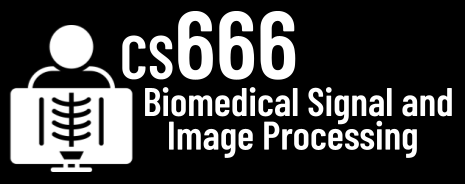

# Assignment 1

In [1]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


**Task 1** (5 pts): Install the BioSPPY library with the following code.

In [2]:
!pip install biosppy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 3.2 MB/s eta 0:00:00


**Task 2** (10 pts): Download a sample ecg dataset from https://cs666.org/data/ecg.txt and upload it to this colab. The following code loads the dataset. Note: this might fail with an import error, but should be an easy fix :)

In [3]:
!pip install peakutils

In [4]:
!wget https://cs666.org/data/ecg.txt

--2026-02-18 18:34:49--  https://cs666.org/data/ecg.txt
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 105085 (103K) [text/plain]
Saving to: ‘ecg.txt’

ecg.txt             100%[===================>] 102.62K  --.-KB/s    in 0.02s   

2026-02-18 18:34:49 (6.38 MB/s) - ‘ecg.txt’ saved [105085/105085]



In [5]:
from biosppy import storage
signal, metadata = storage.load_txt('ecg.txt')

**Task 3** (10 pts): Figure out the sampling rate for this data and how many seconds it lasts.

In [6]:
SAMPLING_RATE = metadata['sampling_rate']
num_samples = len(signal)
SECONDS = (num_samples - 1)/metadata['sampling_rate']

**Task 4** (15 pts): Process the signal with BioSPPY using the `ecg.ecg` method.

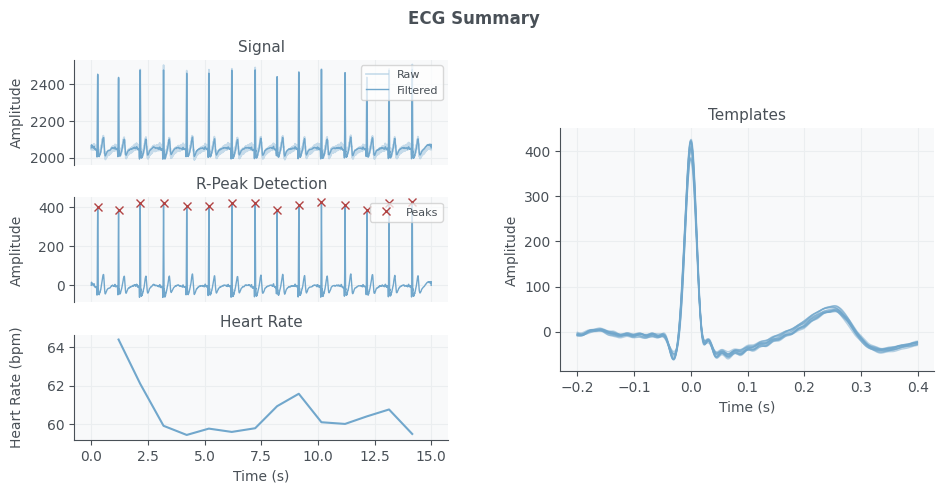

In [7]:
from biosppy.signals import ecg

out = ecg.ecg(signal=signal, sampling_rate=SAMPLING_RATE, show=True)

**Task 5** (10 pts): Plot the first 3 seconds of the unfiltered signal and then the filtered signal. Can you spot the P, Q, R, S, T waves?

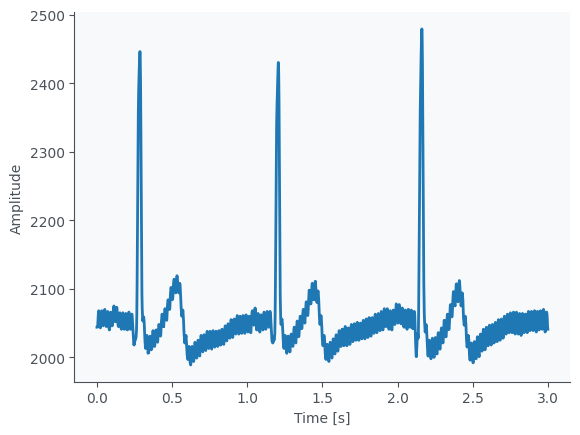

In [8]:
import numpy as np
import matplotlib.pyplot as plt

ts = np.linspace(0, 3, 3000, endpoint=False)  # relative timestamps
plt.plot(ts, signal[0:3000], lw=2)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

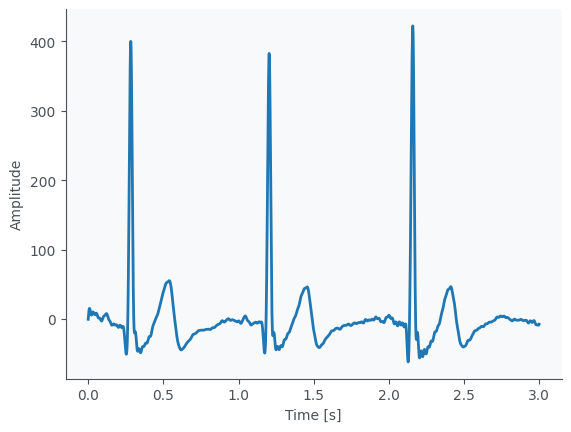

In [10]:
signal_time_axis_reference = out[0]
filtered_ecg_signal = out[1]

ts = signal_time_axis_reference[0:3000]  # relative timestamps
plt.plot(ts, filtered_ecg_signal[0:3000], lw=2)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Answer: The PQRST waves are visible in both un-filtered and filtered signals but they are slightly clearer in the filtered signal.

The PQRST waves are visible in both un-filtered and filtered signals but they are slightly clearer in the filtered signal.

**Task 6** (15 pts): Please plot the whole filtered signal and mark the r-peaks with vertical lines based on the ecg.ecg output. You can use `plt.axvline(x = 100, color = 'r', ls=':')` to create a red, dashed vertical line at position 100. Please label the x-axis as 'time [s]'.

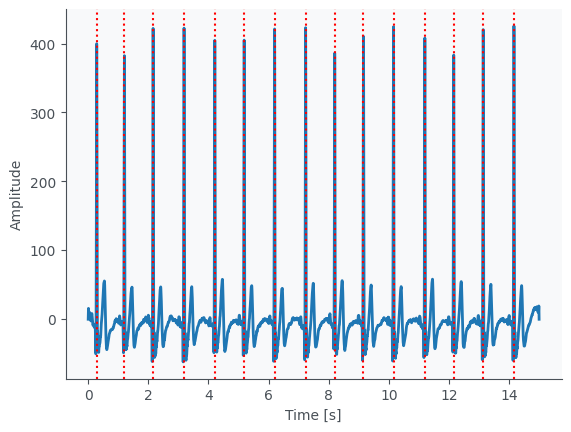

In [19]:
signal_time_axis_reference = out[0]
filtered_ecg_signal = out[1]
r_peaks_biospy = out[2]

ts = signal_time_axis_reference # relative timestamps
plt.plot(ts, filtered_ecg_signal, lw=2)
plt.grid()
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
for r_peak in signal_time_axis_reference[r_peaks_biospy]:
  plt.axvline(x = r_peak, color = 'r', ls=':')
plt.show()

**Task 7** (5 pts): Let's install the NeuroKit2 library.

In [12]:
!pip install neurokit2
import neurokit2 as nk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.4/708.4 kB 12.8 MB/s eta 0:00:00


**Task 8** (20 pts): Detect P Q S T Peaks using Neurokit.

In [ ]:
# We know the R spikes now but what about P Q S T waves?
# TODO Can you use nk.ecg_delineate to detect them in the unfiltred signal?
# Hint: Look at the tutorial: https://neuropsychology.github.io/NeuroKit/examples/ecg_delineate/ecg_delineate.html
# Hint 2: The plot will have blue, orange, green, and red circles :)
# Hint 3: rpeaks were detected above from biosppy's ecg.ecg method

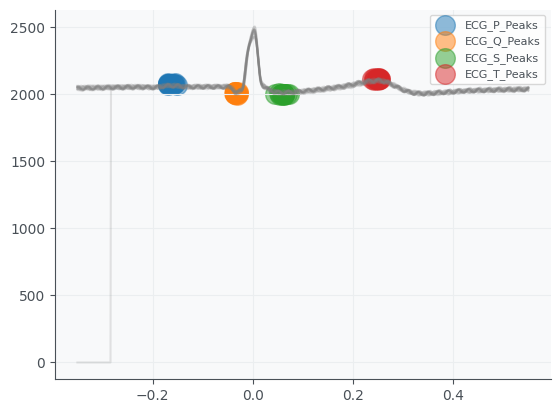

In [20]:
_, waves_peak = nk.ecg_delineate(signal,
                                 r_peaks_biospy,
                                 sampling_rate=SAMPLING_RATE,
                                 method="peak",
                                 show=True,
                                 show_type='peaks')

In [ ]:
# TODO Does the detection work well?

# Answer: No, it doesnt seem like the detection is clear. The P,Q,S,T wave peaks are forming at the correct times and follow the general pattern but the y-axis has some offset and noise in the signal is causing some vagueness in the peak detection.

No, it doesnt seem like the detection is clear. The P,Q,S,T wave peaks are forming at the correct times and follow the general pattern but the y-axis has some offset and noise in the signal is causing some vagueness in the peak detection.

**Task 9** (10 pts): Use the sleepecg library to find the R Peaks.

In [ ]:
# We have the R spikes/peaks now from Biosppy from above but there is another
# library called sleepecg.
# TODO Please install it and run the rpeak detection!
# Docs: https://sleepecg.readthedocs.io/en/stable/

In [21]:
!pip install sleepecg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.6/419.6 kB 8.1 MB/s eta 0:00:00


In [22]:
from sleepecg import detect_heartbeats

r_peaks_sleepecg = detect_heartbeats(signal, SAMPLING_RATE)

In [23]:
# TODO Do Biosppy and sleepecg give different rpeaks? Please calculate the MSE!

# Answer: They give almost similar rpeaks except for 2 peaks.

In [24]:
r_peaks_sleepecg

array([  283,  1203,  2158,  3188,  4211,  5188,  6200,  7232,  8200,
        9157, 10155, 11198, 12159, 13139, 14162])

In [25]:
r_peaks_biospy

array([  283,  1204,  2159,  3188,  4211,  5188,  6200,  7232,  8200,
        9157, 10156, 11198, 12159, 13139, 14162])

In [26]:
from sklearn.metrics import mean_squared_error

mean_squared_error(r_peaks_biospy, r_peaks_sleepecg)

0.2

They give almost similar rpeaks except for 2 peaks.

**Bonus Task** (33 pts): Detect P Q S T Peaks for the full signal before and after filtering.

In [27]:
# TODO As above use the nk.ecg_delineate function to detect peaks for the whole signal

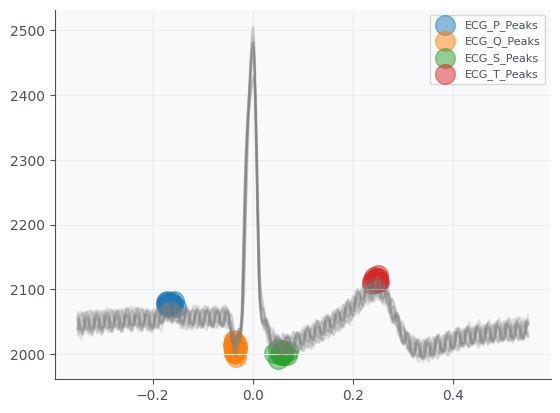

In [28]:
# Unfiltered Signal

_, rpeaks_nk = nk.ecg_peaks(signal, sampling_rate=SAMPLING_RATE)
_, waves_peak = nk.ecg_delineate(signal,
                                 rpeaks_nk,
                                 sampling_rate=SAMPLING_RATE,
                                 method="peak",
                                 show=True,
                                 show_type='peaks')

In [29]:
# TODO Let's filter the signal and see if the detection improves.
# Hint: You can use nk.signal_filter to define a bandpass.
# Hint 2: Which lowcut and highcut frequencies work well? Play with it :)
# Hint 3: You don't need to re-calculate the rpeaks since they are pretty accurate in general.

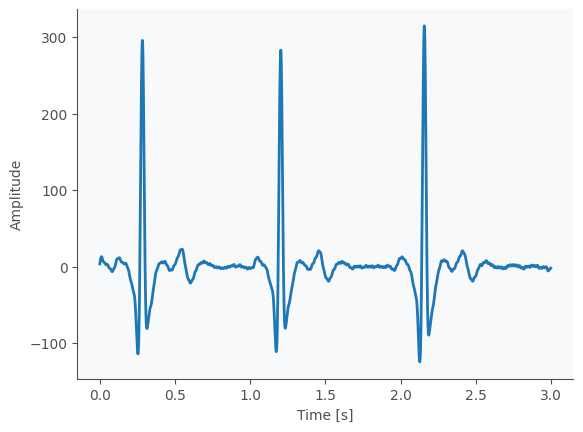

In [30]:
filtered_signal_nk = nk.signal_filter(signal, sampling_rate=SAMPLING_RATE, lowcut=5, highcut=30, method="butterworth", order=2)

# A low cut of 5 and highcut of 30 Hz seem to be working well as the graph generated is clearer.

ts = np.linspace(0, 3, 3000, endpoint=False)  # relative timestamps
plt.plot(ts, filtered_signal_nk[0:3000], lw=2)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [31]:
# Finally, run the delineation on the filtered signal from BioSPPY.

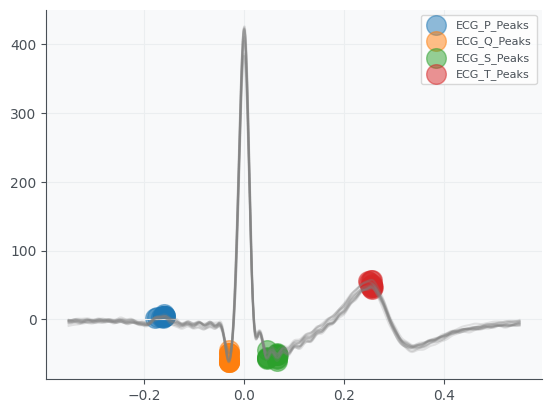

In [32]:
_, rpeaks_nk_filtered = nk.ecg_peaks(filtered_ecg_signal, sampling_rate=SAMPLING_RATE)
_, waves_peak_filtered = nk.ecg_delineate(filtered_ecg_signal,
                                 rpeaks_nk_filtered,
                                 sampling_rate=SAMPLING_RATE,
                                 method="peak",
                                 show=True,
                                 show_type='peaks')

In [33]:
# TODO Which one works the best?

# Answer: The filtered signal from BioSPPY generates a much cleaner waves peaks graph.

The filtered signal from BioSPPY generates a much cleaner waves peaks graph.

In [34]:
#
# Great job!!
#
#  , ; ,   .-'"""'-.   , ; ,
#  \\|/  .'         '.  \|//
#   \-;-/   ()   ()   \-;-/
#   // ;               ; \\
#  //__; :.         .; ;__\\
# `-----\'.'-.....-'.'/-----'
#        '.'.-.-,_.'.'
#jgs       '(  (..-'
#            '-'
#